# Analisi del Sentiment – Dizionario ed Estrazione Lessicale
Notebook autonomo: legge i file Excel, costruisce il dizionario emotivo,
estrae le emozioni nominate esplicitamente e conta caratteri/parole per emozione.

Sezioni:
- 0–3: installazione, configurazione, lettura file Excel
- 4: dizionario emozioni italiane
- 5: funzione di ricerca nel dizionario
- 6: estrazione automatica con KeyBERT
- 7: analisi per file e domanda, conteggio globale, export CSV
- 8: caratteri e parole per emozione (livello periodo)


## 0. Installazione dipendenze


In [1]:
# Esegui solo la prima volta
# !pip install openpyxl pandas keybert sentence-transformers

## 1. Import e configurazione


In [2]:
import re
import os
import pandas as pd
import openpyxl
from pathlib import Path
from collections import defaultdict, Counter

# --- Percorsi ---
CARTELLA_RISPOSTE = Path("risposte")  # sottocartella relativa al notebook
SHEET_NAME        = "PRE_CONS"
N_FILE            = 22

# Colonne (0-based) che contengono domande (riga 1) e risposte (riga 2)
COLONNE_DOMANDE = [1, 3, 5, 7, 9, 11]  # B, D, F, H, J, L

print("Librerie caricate correttamente")


Librerie caricate correttamente


## 2. Congiunzioni italiane (usate per lo split in periodi)


In [3]:
CONGIUNZIONI = [
    "ma", "però", "tuttavia", "eppure", "anzi", "invece",
    "e", "ed", "anche", "inoltre", "pure",
    "allora", "quindi", "dunque", "perciò", "così",
    "perché", "poiché", "siccome",
    "se", "quando", "mentre", "sebbene", "benché",
    "oppure", "o", "ovvero", "altrimenti"
]
print(f"Congiunzioni caricate: {len(CONGIUNZIONI)}")


Congiunzioni caricate: 28


## 3. Lettura dei 22 file Excel


In [4]:
def leggi_file(numero: int) -> dict | None:
    """
    Legge il file XX_risposte.xlsx e restituisce un dict con:
      file, domande (lista 6), risposte (lista 6)
    """
    nome_file = CARTELLA_RISPOSTE / f"{numero:02d}_risposte.xlsx"

    if not nome_file.exists():
        print(f"  ⚠️  File non trovato: {nome_file}")
        return None

    try:
        wb = openpyxl.load_workbook(nome_file, read_only=True, data_only=True)

        if SHEET_NAME not in wb.sheetnames:
            print(f"  ⚠️  Foglio '{SHEET_NAME}' non trovato in {nome_file.name}")
            print(f"       Fogli disponibili: {wb.sheetnames}")
            return None

        ws   = wb[SHEET_NAME]
        rows = list(ws.iter_rows(min_row=1, max_row=2, values_only=True))

        if len(rows) < 2:
            print(f"  ⚠️  Il foglio {SHEET_NAME} in {nome_file.name} ha meno di 2 righe")
            return None

        riga_domande  = rows[0]
        riga_risposte = rows[1]

        domande  = []
        risposte = []

        for col in COLONNE_DOMANDE:
            d = riga_domande[col]  if col < len(riga_domande)  else None
            r = riga_risposte[col] if col < len(riga_risposte) else None
            domande.append(str(d).strip() if d else "")
            risposte.append(str(r).strip() if r else "")

        return {
            "file":     nome_file.name,
            "numero":   numero,
            "domande":  domande,
            "risposte": risposte
        }

    except Exception as e:
        print(f"  ❌ Errore leggendo {nome_file.name}: {e}")
        return None


# Carica tutti i file
print(f"Lettura di {N_FILE} file da '{CARTELLA_RISPOSTE}/'...\n")
dati_grezzi = []

for i in range(1, N_FILE + 1):
    dati = leggi_file(i)
    if dati:
        dati_grezzi.append(dati)
        print(f"  ✅ {dati['file']} — {sum(1 for r in dati['risposte'] if r)} risposte trovate")

print(f"\nFile caricati correttamente: {len(dati_grezzi)}/{N_FILE}")

Lettura di 22 file da 'risposte/'...

  ✅ 01_risposte.xlsx — 6 risposte trovate
  ✅ 02_risposte.xlsx — 6 risposte trovate
  ✅ 03_risposte.xlsx — 6 risposte trovate
  ✅ 04_risposte.xlsx — 6 risposte trovate
  ✅ 05_risposte.xlsx — 6 risposte trovate
  ✅ 06_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: risposte\07_risposte.xlsx
  ⚠️  File non trovato: risposte\08_risposte.xlsx
  ✅ 09_risposte.xlsx — 6 risposte trovate
  ✅ 10_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: risposte\11_risposte.xlsx
  ✅ 12_risposte.xlsx — 6 risposte trovate
  ✅ 13_risposte.xlsx — 6 risposte trovate
  ✅ 14_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: risposte\15_risposte.xlsx
  ✅ 16_risposte.xlsx — 6 risposte trovate
  ✅ 17_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: risposte\18_risposte.xlsx
  ⚠️  File non trovato: risposte\19_risposte.xlsx
  ⚠️  File non trovato: risposte\20_risposte.xlsx
  ✅ 21_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: 

---
## 4. Estrazione emozioni nominate esplicitamente
Due approcci combinati:
- **Dizionario**: lista fissa di termini emotivi italiani con lemmatizzazione semplice
- **Automatico**: KeyBERT per estrarre automaticamente parole chiave emotive non previste dal dizionario

In [5]:
# Installa keybert se non presente
# !pip install keybert sentence-transformers

### 4a. Dizionario emozioni italiane

In [6]:
import re
from collections import Counter

# ---------------------------------------------------------------------------
# Dizionario emotivo italiano — ESPANSO con Ruota delle Emozioni
# Ogni voce: forma base -> varianti (singolare, plurale, verbo, avverbio...)
# ---------------------------------------------------------------------------
DIZIONARIO_EMOZIONI = {
    # ── GIOIA / POSITIVO ────────────────────────────────────────────────────
    "gioia":           ["gioia", "gioioso", "gioiosa", "gioiosamente"],
    "felicità":        ["felicità", "felice", "felici", "felicemente"],
    "entusiasmo":      ["entusiasmo", "entusiasta", "entusiasti", "entusiasmato", "entusiasmata"],
    "sollievo":        ["sollievo", "sollevato", "sollevata", "sollevati"],
    "speranza":        ["speranza", "speranzoso", "speranzosa", "sperare", "spero"],
    "soddisfazione":   ["soddisfazione", "soddisfatto", "soddisfatta", "soddisfatti", "rispettato", "rispettata"],
    "curiosità":       ["curiosità", "curioso", "curiosa", "curiosi"],
    "gratitudine":     ["gratitudine", "grato", "grata", "grati", "riconoscente"],
    "orgoglio":        ["orgoglio", "orgoglioso", "orgogliosa", "orgogliosamente"],
    "fiducia":         ["fiducia", "fiducioso", "fiduciosa", "fiducioso"],
    "serenità":        ["serenità", "sereno", "serena", "serenamente"],
    "ottimismo":       ["ottimismo", "ottimista", "ottimisti", "ottimistico"],
    "amore":           ["amore", "amato", "amata", "amare", "amo", "amorevole", "amorevoli"],
    "affetto":         ["affetto", "affettuoso", "affettuosa"],
    "aspettativa":     ["aspettativa", "aspettative", "aspettarsi", "mi aspettavo"],
    "contentezza":     ["contentezza", "contento", "contenta", "contenti"],
    # Ruota — felicità
    "potenza":         ["potente", "potenti", "mi sento potente", "forza interiore"],
    "tranquillità":    ["tranquillo", "tranquilla", "tranquilli", "tranquillità", "tranquillamente"],
    "intimità":        ["intimo", "intima", "intimi", "intimità"],
    "interesse":       ["interessato", "interessata", "interessati", "interesse"],
    "accettazione":    ["accettato", "accettata", "accettati", "accettazione", "accoglienza"],
    "divertimento":    ["divertito", "divertita", "divertiti", "divertimento", "divertente"],
    "giocosità":       ["giocoso", "giocosa", "giocosi", "giocosità", "giocoso"],
    "delicatezza":     ["delicato", "delicata", "delicati", "delicatezza"],
    "estasi":          ["estasiato", "estasiata", "estasiati", "estasi"],
    "liberazione":     ["liberato", "liberata", "liberati", "liberazione", "libero", "libera"],
    "ispirazione":     ["ispirato", "ispirata", "ispirati", "ispirazione", "ispirarsi"],
    "apertura":        ["aperto", "aperta", "aperti", "apertura"],
    "coraggio":        ["coraggioso", "coraggiosa", "coraggiosi", "coraggio", "coraggiosamente"],
    "importanza":      ["importante", "importanti", "mi sento importante", "valorizzato", "valorizzata"],

    # ── TRISTEZZA ───────────────────────────────────────────────────────────
    "tristezza":       ["tristezza", "triste", "tristi", "tristemente"],
    "malinconia":      ["malinconia", "malinconico", "malinconica", "malinconici"],
    "dolore":          ["dolore", "doloroso", "dolorosa", "soffrire", "soffro"],
    "sofferenza":      ["sofferenza", "sofferente", "sofferenti"],
    "dispiacere":      ["dispiacere", "dispiaciuto", "dispiaciuta", "mi dispiace"],
    "delusione":       ["delusione", "deluso", "delusa", "delusi", "deludente"],
    "sconforto":       ["sconforto", "sconfortato", "sconfortata", "scoraggiato", "scoraggiata"],
    "disperazione":    ["disperazione", "disperato", "disperata", "disperati"],
    "solitudine":      ["solitudine", "solo", "sola", "soli", "isolato", "isolata"],
    "rimpianto":       ["rimpianto", "rimpianti", "rimpiangere"],
    "depressione":     ["depressione", "depresso", "depressa", "depressi", "depressivi"],
    "negativo":        ["negativo", "negativi", "negativa"],
    "abbandono":       ["abbandono", "abbandonato", "abbandonata", "abbandonati"],
    # Ruota — tristezza
    "perplessità":     ["perplesso", "perplessa", "perplessi", "perplessità"],
    "disillusione":    ["disilluso", "disillusa", "disillusione", "disingannato"],
    "impotenza":       ["impotente", "impotenti", "impotenza", "mi sento impotente"],
    "inferiorità":     ["inferiore", "inferiori", "inferiorità", "mi sento inferiore"],
    "vuoto":           ["vuoto", "vuota", "vuoti", "sento il vuoto", "senso di vuoto"],
    "indifferenza":    ["indifferente", "indifferenti", "indifferenza"],
    "apatia":          ["apatico", "apatica", "apatici", "apatia"],
    "vittimizzazione": ["vittimizzato", "vittimizzata", "vittimizzati", "mi sento vittima"],
    "ignorato":        ["ignorato", "ignorata", "ignorati", "invisibile", "non visto", "non vista"],
    "noia":            ["annoiato", "annoiata", "annoiati", "noia", "annoiante"],
    "meraviglia":      ["meraviglia", "meraviglioso", "meravigliosa", "meravigliati"],
    "stupore":         ["stupore", "stupito", "stupita", "stupefatto", "stupefatta"],
    "malessere":       ["malessere", "stare male", "sto male", "stavo male"],

    # ── PAURA / ANSIA ───────────────────────────────────────────────────────
    "paura":           ["paura", "pauroso", "paurosa", "aver paura", "ho paura", "impaurito", "impaurita"],
    "ansia":           ["ansia", "ansioso", "ansiosa", "ansiosi", "ansiosamente"],
    "preoccupazione":  ["preoccupazione", "preoccupato", "preoccupata", "preoccuparsi"],
    "timore":          ["timore", "timoroso", "timorosa", "temere", "temo"],
    "terrore":         ["terrore", "terrorizzato", "terrorizzata"],
    "angoscia":        ["angoscia", "angosciato", "angosciata", "angoscioso"],
    "inquietudine":    ["inquietudine", "inquieto", "inquieta", "inquieti"],
    "insicurezza":     ["insicurezza", "insicuro", "insicura", "insicuri"],
    "incertezza":      ["incertezza", "incerto", "incerta", "incerti"],
    "vulnerabilità":   ["vulnerabilità", "vulnerabile", "vulnerabili"],
    # Ruota — paura
    "rifiuto":         ["respinto", "respinta", "respinti", "rifiutato", "rifiutata", "rifiuto"],
    "umiliazione":     ["umiliato", "umiliata", "umiliati", "umiliazione"],
    "inadeguatezza":   ["inadeguato", "inadeguata", "inadeguati", "inadeguatezza", "mi sento inadeguato"],
    "irrispettato":    ["irrispettato", "irrispettata", "irrispettati", "non rispettato"],
    "ridicolizzato":   ["ridicolizzato", "ridicolizzata", "deriso", "derisa", "preso in giro"],
    "alienazione":     ["alienato", "alienata", "alienati", "alienazione", "estraniato"],
    "insignificanza":  ["insignificante", "insignificanti", "mi sento insignificante"],
    "indegnità":       ["indegno", "indegna", "indegni", "indegnità"],
    "sopraffazione":   ["sopraffatto", "sopraffatta", "sopraffatti", "sopraffazione"],
    "sottomissione":   ["sottomesso", "sottomessa", "sottomessi", "sottomissione"],

    # ── RABBIA ──────────────────────────────────────────────────────────────
    "rabbia":          ["rabbia", "arrabbiato", "arrabbiata", "arrabbiati"],
    "frustrazione":    ["frustrazione", "frustrato", "frustrata", "frustrati", "frustrante"],
    "irritazione":     ["irritazione", "irritato", "irritata", "irritabile", "irritato"],
    "risentimento":    ["risentimento", "risentito", "risentita"],
    "indignazione":    ["indignazione", "indignato", "indignata"],
    "collera":         ["collera", "in collera"],
    "odio":            ["odio", "odiare", "detestare"],
    # Ruota — rabbia
    "aggressività":    ["aggressivo", "aggressiva", "aggressivi", "aggressività"],
    "critica":         ["critico", "critica", "critici", "criticare", "critico"],
    "distacco":        ["distaccato", "distaccata", "distaccati", "distacco"],
    "furia":           ["furioso", "furiosa", "furiosi", "furia"],
    "imbestialito":    ["imbestialito", "imbestialita", "imbestialiti"],
    "devastato":       ["devastato", "devastata", "devastati", "devastazione"],
    "violato":         ["violato", "violata", "violati", "mi sento violato"],
    "rancore":         ["rancoroso", "rancorosa", "rancorosi", "rancore"],
    "infuriato":       ["infuriato", "infuriata", "infuriati"],
    "asociale":        ["asociale", "asociali"],
    "sospetto":        ["sospettoso", "sospettosa", "sospettosi", "sospetto"],
    "sarcasmo":        ["sarcastico", "sarcastica", "sarcastici", "sarcasmo"],
    "ostilità":        ["ostile", "ostili", "ostilità"],
    "provocazione":    ["provocato", "provocata", "provocatorio", "provocazione"],
    "minaccia":        ["minacciato", "minacciata", "minacciati", "minaccia"],
    "ferito":          ["ferito", "ferita", "feriti", "mi sento ferito"],
    "detestabile":     ["detestabile", "detestabili"],
    "geloso":          ["geloso", "gelosa", "gelosia", "gelosia"],
    "eccitazione":     ["eccitato", "eccitata", "eccitati", "eccitazione", "energico", "energica"],

    # ── SORPRESA / CONFUSIONE ───────────────────────────────────────────────
    "sorpresa":        ["sorpresa", "sorpreso", "sorpresi", "sorprendente"],
    "confusione":      ["confusione", "confuso", "confusa", "confusi"],
    "disorientamento": ["disorientamento", "disorientato", "disorientata"],
    "scioccato":       ["scioccato", "scioccata", "scioccati", "shock", "sotto shock"],

    # ── DISGUSTO ────────────────────────────────────────────────────────────
    "disgusto":        ["disgusto", "disgustato", "disgustata", "disgustoso"],
    "repulsione":      ["repulsione", "repulsivo", "ripugnante", "ripugnanti"],
    "disapprovazione": ["disapprovazione", "disapprovo", "disapprovato", "non approvo"],
    "avversione":      ["avversione", "contrario", "avverso"],
    "orrore":          ["orrore", "orribile", "orripilato", "orripilante"],
    "ribellione":      ["ribelle", "ribelli", "ribellione", "mi ribello"],
    "giudizio":        ["giudicante", "giudicato", "giudicata", "mi sento giudicato"],
    "esitazione":      ["esitante", "esitanti", "esitazione", "incerto su"],
    "sfuggevolezza":   ["sfuggente", "sfuggevolezza", "schivo", "schiva"],

    # ── VERGOGNA / COLPA ────────────────────────────────────────────────────
    "vergogna":        ["vergogna", "vergognoso", "vergognosa", "vergognarsi"],
    "colpa":           ["colpa", "colpevole", "colpevoli", "senso di colpa"],
    "imbarazzo":       ["imbarazzo", "imbarazzato", "imbarazzata", "imbarazzante"],

    # ── NEUTRO / STATO ──────────────────────────────────────────────────────
    "benessere":       ["benessere", "stare bene", "sto bene", "stavo bene"],
    "stanchezza":      ["stanchezza", "stanco", "stanca", "stanchi", "esausto", "esausta"],
    "nostalgia":       ["nostalgia", "nostalgico", "nostalgica"],
    "pensieroso":      ["pensieroso", "pensoso", "tanti pensieri", "penso tanto"],
    "desiderio":       ["desiderio", "desideroso", "desiderare", "desidero"],
    "scoraggiamento":  ["scoraggiato", "scoraggiata", "scoraggiati", "scoraggiamento"],
}

# Mappa inversa: variante -> forma base
MAPPA_INVERSA = {}
for forma_base, varianti in DIZIONARIO_EMOZIONI.items():
    for v in varianti:
        MAPPA_INVERSA[v.lower()] = forma_base

print(f"✅ Dizionario caricato: {len(DIZIONARIO_EMOZIONI)} emozioni, "
      f"{len(MAPPA_INVERSA)} varianti totali")


✅ Dizionario caricato: 124 emozioni, 512 varianti totali


### 4b. Funzione di ricerca nel dizionario

In [7]:
def trova_emozioni_dizionario(testo: str) -> list[dict]:
    trovate = []
    testo_lower = testo.lower()

    for variante, forma_base in MAPPA_INVERSA.items():
        if " " in variante:
            # Frase multi-parola: ammette fino a 3 parole opzionali in mezzo
            parole = variante.split()
            pattern = r"\b" + r"\b(?:\s+\S+){0,3}\s+\b".join(
                re.escape(p) for p in parole
            ) + r"\b"
        else:
            pattern = r"\b" + re.escape(variante) + r"\b"

        for match in re.finditer(pattern, testo_lower):
            trovate.append({
                "forma_base": forma_base,
                "variante":   match.group(),
                "posizione":  match.start(),
                "contesto":   testo[max(0, match.start()-30):match.end()+30].strip()
            })

    trovate.sort(key=lambda x: x["posizione"])
    return trovate

### 4c. Estrazione automatica con KeyBERT

In [14]:
from keybert import KeyBERT
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Modello multilingua per italiano
print("Caricamento KeyBERT (modello multilingua)...")
kw_model = KeyBERT(model="paraphrase-multilingual-MiniLM-L12-v2")
print("✅ KeyBERT pronto")

# Lista di parole emotive note (usata come seed per guidare KeyBERT)
SEED_EMOTIVO = list(DIZIONARIO_EMOZIONI.keys())

def trova_emozioni_automatico(testo: str, top_n: int = 10) -> list[tuple]:
    """
    Usa KeyBERT per estrarre le parole più simili semanticamente
    al vocabolario emotivo. Restituisce lista di (parola, score).
    Filtra i risultati già coperti dal dizionario per mostrare
    solo i suggerimenti nuovi.
    """
    if not testo or len(testo.split()) < 5:
        return []

    try:
        keywords = kw_model.extract_keywords(
            testo,
            keyphrase_ngram_range=(1, 4),   # fino a 4 parole
            stop_words=None,
            top_n=top_n,
            seed_keywords=SEED_EMOTIVO,      # guida verso termini emotivi
            use_mmr=True,                    # diversifica i risultati
            diversity=0.5
        )
    except Exception as e:
        return []

    # Filtra: tieni solo quelli NON già nel dizionario
    nuovi = [
        (kw, round(score, 3))
        for kw, score in keywords
        if kw.lower() not in MAPPA_INVERSA and score > 0.25
    ]
    return nuovi


print("✅ Funzione KeyBERT pronta")

Caricamento KeyBERT (modello multilingua)...
✅ KeyBERT pronto
✅ Funzione KeyBERT pronta


### 4d. Analisi completa: emozioni nominate per file e domanda

In [15]:
righe_emozioni = []   # per il DataFrame dettagliato
contatore_globale = Counter()   # conteggio globale per forma base

# ── Dizionario intensificatori (locale, autosufficiente) ─────────────────────
_INTENS_LOCAL = {
    "non": "negazione", "per niente": "negazione", "affatto": "negazione",
    "molto": "alto", "tanto": "alto", "davvero": "alto", "veramente": "alto",
    "assai": "alto", "estremamente": "alto", "totalmente": "alto",
    "completamente": "alto", "profondamente": "alto", "fortemente": "alto",
    "incredibilmente": "alto", "enormemente": "alto", "tremendamente": "alto",
    "abbastanza": "medio", "piuttosto": "medio", "alquanto": "medio",
    "discretamente": "medio",
    "poco": "basso", "appena": "basso", "quasi": "basso",
    "leggermente": "basso", "lievemente": "basso",
    "un po": "basso", "un po'": "basso",
    "moltissimo": "superlativo", "tantissimo": "superlativo",
}
_INTENS_SORTED_LOCAL = sorted(_INTENS_LOCAL.keys(), key=len, reverse=True)


def _trova_intens_locale(testo, match_start, match_end=None):
    """
    Cerca TUTTI gli intensificatori presenti:
    - nelle 4 parole prima del termine emotivo
    - all'interno del match stesso (per frasi multi-parola come 'stavo molto male')
    Restituisce lista di (token, categoria), vuota se non trovati.
    """
    prima  = " ".join(testo[:match_start].split()[-4:]).lower()
    dentro = testo[match_start:match_end].lower() if match_end else ""
    testo_cerca = (prima + " " + dentro).strip()

    trovati    = []
    gia_trovati = set()
    for token in _INTENS_SORTED_LOCAL:
        if token not in gia_trovati and re.search(
            r"\b" + re.escape(token) + r"\b", testo_cerca
        ):
            trovati.append((token, _INTENS_LOCAL[token]))
            gia_trovati.add(token)
    return trovati   # lista vuota se nessuno trovato


def _fmt_intens(intens_list):
    """Formatta la lista intensificatori per la stampa."""
    if not intens_list:
        return "—"
    return ", ".join(f"{tok} [{cat}]" for tok, cat in intens_list)


# ── Loop principale ───────────────────────────────────────────────────────────
for dati in dati_grezzi:
    print(f"\n{'='*60}")
    print(f"📄 File: {dati['file']}")
    print(f"{'='*60}")

    for idx, (domanda, risposta) in enumerate(zip(dati["domande"], dati["risposte"])):
        if not risposta:
            continue

        print(f"\n  🔹 Domanda {idx+1}: {domanda[:70]}...")

        # --- APPROCCIO 1: Dizionario ---
        trovate_diz = trova_emozioni_dizionario(risposta)
        forme_trovate = [t["forma_base"] for t in trovate_diz]
        contatore_domanda = Counter(forme_trovate)
        contatore_globale.update(contatore_domanda)

        risposta_lower = risposta.lower()

        # ── Tabella per risposta ──────────────────────────────────────────────
        if trovate_diz:
            SEP  = "  " + "-" * 82
            HEAD = f"  {'CONTESTO':<35} {'EMOZIONE':<18} {'VARIANTE':<16} INTENSIFICATORI"
            print(f"\n     📖 Dizionario — {len(trovate_diz)} occorrenze trovate:")
            print(f"  {SEP[2:]}")
            print(HEAD)
            print(SEP)

            for i, t in enumerate(trovate_diz):
                contesto      = t["contesto"][:33].strip()
                contesto_fmt  = (contesto + "…") if len(t["contesto"].strip()) > 33 else contesto
                match_end     = t["posizione"] + len(t["variante"])
                intens_list   = _trova_intens_locale(risposta_lower, t["posizione"], match_end)
                intens_str    = _fmt_intens(intens_list)

                # Segnala vicinanza con l'occorrenza precedente
                if i > 0:
                    prev = trovate_diz[i - 1]
                    testo_tra = risposta[prev["posizione"] + len(prev["variante"]):t["posizione"]]
                    if len(re.sub(r"[\s,]", "", testo_tra.lower())) <= 30:
                        print(f"  {'':<35} ↕ vicina a: {trovate_diz[i-1]['forma_base']}")

                print(f"  \"{contesto_fmt:<34}\" {t['forma_base']:<18} {t['variante']:<16} {intens_str}")

            print(SEP)
        else:
            print("     📖 Dizionario — nessuna emozione trovata")

        # --- APPROCCIO 2: KeyBERT ---
        nuovi_kw = trova_emozioni_automatico(risposta)
        if nuovi_kw:
            print(f"     🤖 KeyBERT — suggerimenti nuovi:")
            for kw, score in nuovi_kw:
                print(f"       ~ {kw:<22} (similarità: {score:.3f})")
        else:
            print("     🤖 KeyBERT — nessun termine nuovo rilevante")

        # ── Salva righe dettaglio ─────────────────────────────────────────────
        for t in trovate_diz:
            match_end   = t["posizione"] + len(t["variante"])
            intens_list = _trova_intens_locale(risposta_lower, t["posizione"], match_end)
            righe_emozioni.append({
                "file":               dati["file"],
                "numero":             dati["numero"],
                "domanda_n":          idx + 1,
                "forma_base":         t["forma_base"],
                "variante":           t["variante"],
                "contesto":           t["contesto"],
                "intensificatore":    ", ".join(tok for tok, _ in intens_list) if intens_list else None,
                "intensificatore_cat":  ", ".join(cat for _, cat in intens_list) if intens_list else None,
                "metodo":             "dizionario",
            })
        for kw, score in nuovi_kw:
            righe_emozioni.append({
                "file":               dati["file"],
                "numero":             dati["numero"],
                "domanda_n":          idx + 1,
                "forma_base":         kw,
                "variante":           kw,
                "contesto":           f"score similarità: {score}",
                "intensificatore":    None,
                "intensificatore_cat": None,
                "metodo":             "keybert",
            })

print("\n\n✅ Estrazione emozioni nominate completata")



📄 File: 01_risposte.xlsx

  🔹 Domanda 1: Q1. Quali sono i motivi che l'hanno portata a cercare un percorso diag...

     📖 Dizionario — 6 occorrenze trovate:
  ----------------------------------------------------------------------------------
  CONTESTO                            EMOZIONE           VARIANTE         INTENSIFICATORI
  ----------------------------------------------------------------------------------
  ""Principalmente perché stavo davv…" malessere          stavo davvero molto male davvero [alto], molto [alto]
  "supporto farmacologico per l'ansi…" ansia              ansia            —
                                      ↕ vicina a: ansia
  "armacologico per l'ansia e la dep…" depressione        depressione      —
  "brava che le sole diagnosi di dep…" depressione        depressione      —
                                      ↕ vicina a: depressione
  "le diagnosi di depressione ed ans…" ansia              ansia            —
  "tà e ""stranezze"" quindi ero int…" inte

### 4e. Conteggio globale delle emozioni nominate

In [16]:
print("\n" + "="*55)
print("  EMOZIONI PIÙ NOMINATE — CORPUS COMPLETO (dizionario)")
print("="*55)

for emozione, count in contatore_globale.most_common():
    barra_c = "█" * min(count, 40)
    print(f"  {emozione:<22} {barra_c} {count}")


  EMOZIONI PIÙ NOMINATE — CORPUS COMPLETO (dizionario)
  ansia                  ███████████████ 15
  curiosità              ██████████ 10
  speranza               █████████ 9
  solitudine             █████████ 9
  frustrazione           ████████ 8
  aspettativa            ██████ 6
  paura                  ██████ 6
  depressione            █████ 5
  malessere              ████ 4
  interesse              ████ 4
  sollievo               ████ 4
  negativo               ████ 4
  confusione             ███ 3
  rabbia                 ███ 3
  entusiasmo             ███ 3
  apertura               ███ 3
  sofferenza             ███ 3
  soddisfazione          ██ 2
  gratitudine            ██ 2
  ignorato               ██ 2
  imbarazzo              ██ 2
  benessere              █ 1
  colpa                  █ 1
  terrore                █ 1
  vuoto                  █ 1
  desiderio              █ 1
  dolore                 █ 1
  felicità               █ 1
  preoccupazione         █ 1
  timore       

### 4f. DataFrame dettagliato ed export CSV

In [17]:
df_emozioni = pd.DataFrame(righe_emozioni)

print(f"Totale occorrenze registrate: {len(df_emozioni)}")
print(f"Metodi: {df_emozioni['metodo'].value_counts().to_dict()}\n")

# ── Lavoriamo solo sulle occorrenze del dizionario ────────────────────────────
df_diz_4d = df_emozioni[df_emozioni["metodo"] == "dizionario"].copy()

# ── Pivot base: conteggio occorrenze per (partecipante x emozione) ────────────
# Ogni riga = un partecipante, ogni colonna = una forma_base
# Il valore è il numero di volte che quella emozione appare nelle risposte
df_pivot = (
    df_diz_4d
    .groupby(["numero", "forma_base"])
    .size()
    .unstack(fill_value=0)
)
print("Matrice conteggi emozioni x partecipante (solo dizionario):")
display(df_pivot)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# ── Pivot arricchito: conteggio + intensificatori per (partecipante x emozione)
# Gli intensificatori vengono raccolti da df_emozioni (stessa fonte dei conteggi)
# e deduplicati: se lo stesso intensificatore appare più volte per lo stesso
# partecipante+emozione, viene riportato una volta sola.

# Raggruppa intensificatori non nulli per (numero, forma_base)
intens_per_file = (
    df_diz_4d[df_diz_4d["intensificatore"].notna()]
    .groupby(["numero", "forma_base"])["intensificatore"]
    .apply(lambda s: ", ".join(sorted(set(
        i.strip()
        for cell in s
        for i in str(cell).split(",")
        if i.strip()
    ))))
    .unstack(fill_value="")
)

# Costruisce il pivot arricchito con colonne interleaved:
# emozione_A conteggio | emozione_A intensificatori | emozione_B conteggio | ...
cols_emo = df_pivot.columns.tolist()
df_pivot_arricchito = pd.DataFrame(index=df_pivot.index)

for emo in cols_emo:
    df_pivot_arricchito[(emo, "conteggio")] = df_pivot[emo]
    if emo in intens_per_file.columns:
        df_pivot_arricchito[(emo, "intensificatori")] = (
            intens_per_file[emo].reindex(df_pivot.index, fill_value="")
        )
    else:
        df_pivot_arricchito[(emo, "intensificatori")] = ""

df_pivot_arricchito.columns = pd.MultiIndex.from_tuples(
    df_pivot_arricchito.columns
)

print("\nMatrice emozioni + intensificatori per partecipante:")
display(df_pivot_arricchito)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# ── Verifica coerenza conteggi ────────────────────────────────────────────────
# Controlla che la somma delle colonne conteggio nel pivot arricchito
# coincida con il totale di df_diz_4d (nessuna occorrenza persa o duplicata)
tot_pivot = df_pivot.values.sum()
tot_diz   = len(df_diz_4d)
if tot_pivot == tot_diz:
    print(f"\n✅ Conteggi coerenti: {tot_pivot} occorrenze totali")
else:
    print(f"\n⚠️  Discrepanza conteggi: pivot={tot_pivot}, df_emozioni={tot_diz}")

# ── Export ────────────────────────────────────────────────────────────────────
df_emozioni.to_csv("emozioni_nominate_dettaglio.csv", index=False, encoding="utf-8-sig")
df_pivot.to_csv("emozioni_nominate_pivot.csv", encoding="utf-8-sig")
df_pivot_arricchito.to_csv("emozioni_nominate_pivot_arricchito.csv", encoding="utf-8-sig")
print("✅ Salvati: 'emozioni_nominate_dettaglio.csv', "
      "'emozioni_nominate_pivot.csv' e 'emozioni_nominate_pivot_arricchito.csv'")


Totale occorrenze registrate: 894
Metodi: {'keybert': 768, 'dizionario': 126}

Matrice conteggi emozioni x partecipante (solo dizionario):


forma_base,accettazione,ansia,apertura,aspettativa,avversione,benessere,colpa,confusione,critica,curiosità,depressione,desiderio,dolore,entusiasmo,felicità,frustrazione,gratitudine,ignorato,imbarazzo,importanza,inadeguatezza,incertezza,insignificanza,interesse,malessere,negativo,paura,preoccupazione,rabbia,scoraggiamento,soddisfazione,sofferenza,solitudine,sollievo,speranza,stanchezza,terrore,timore,tranquillità,vuoto
numero,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,2,0,2,0,1,0,1,0,1,2,0,0,0,0,2,0,0,0,0,0,0,0,1,4,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
2,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0
5,0,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,4,0,3,0,0,0,0,0
6,0,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,1,0,1,0,0,1
9,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
10,0,1,0,0,0,0,0,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
12,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,2,0,2,0,1,0,0,0,0,1,1,0,0,0,1,0,0



Matrice emozioni + intensificatori per partecipante:


accettazione                     ansia                  apertura  \
          conteggio intensificatori conteggio intensificatori conteggio   
numero                                                                    
1                 0                         2                         0   
2                 0                         0                         0   
3                 0                         0                         0   
4                 0                         0                         0   
5                 0                         5                         0   
6                 0                         3                         0   
9                 0                         0                         0   
10                0                         1                         0   
12                0                         0                         1   
13                0                         2                         0   
14                0                         0                         0   
16                0                         0                         0   
17                1                         0                         0   
21                0                         2                         2   

                       aspettativa                 avversione                  \
       intensificatori   conteggio intensificatori  conteggio intensificatori   
numero                                                                          
1                                2                          0                   
2                                1                          0                   
3                                0                          0                   
4                                0                          0                   
5                                1                          0                   
6                                0                          0                   
9                                1                          0                   
10                               0                          0                   
12                               0                          0                   
13                               0                          0                   
14                               0                          1                   
16                               1                          0                   
17                               0                          0                   
21                               0                          0                   

       benessere                     colpa                  confusione  \
       conteggio intensificatori conteggio  intensificatori  conteggio   
numero                                                                   
1              1                         0                           1   
2              0                         1  incredibilmente          0   
3              0                         0                           0   
4              0                         0                           0   
5              0                         0                           0   
6              0                         0                           0   
9              0                         0                           0   
10             0                         0                           0   
12             0                         0                           1   
13             0                         0                           0   
14             0                         0                           0   
16             0                         0                           1   
17             0                         0                           0   
21             0                         0                           0   

                         critica                 curiosità                  \
       intensifi


✅ Conteggi coerenti: 126 occorrenze totali
✅ Salvati: 'emozioni_nominate_dettaglio.csv', 'emozioni_nominate_pivot.csv' e 'emozioni_nominate_pivot_arricchito.csv'


## 8. Caratteri e parole per emozione — dizionario (livello periodo) v3
Logica di attribuzione:

**Emozioni VICINE** → blocco unico, frase intera attribuita a ciascuna emozione.
Sono considerate vicine se il testo tra loro e composto solo da:
- connettori additivi: `e`, `anche`, `inoltre`...
- espressioni ponte di intensita: `pieno di`, `carico di`, `colmo di`, `traboccante di`...
- intensificatori: `molto`, `abbastanza`, `totalmente`...
- virgole e spazi

**Emozioni DISTANTI** → split alla congiunzione avversativa/temporale (`ma`, `poi`, `pero`, `mentre`...).
Ogni sotto-periodo riceve la propria emozione con il proprio conteggio.

**Intensificatori** rilevati nelle 3 parole prima di ogni termine emotivo.
Output aggiuntivi nel CSV: `intensificatore`, `intensificatore_cat`.

Funzioni sezione 8 v3 definite

  DEMO — esempi di analisi

────────────────────────────────────────────────────────────────────────────────
FRASE: "Ero molto felice perche Gaia mi ha abbracciato ma poi mi sono sentito triste."
Totale risposta → 14 parole · 77 caratteri
────────────────────────────────────────────────────────────────────────────────
  EMOZIONE           INTENSIFICATORE             PAR   %PAR   CAR   %CAR   TESTO ATTRIBUITO
  ────────────────── ────────────────────────── ──── ──────  ──── ──────   ────────────────────────────
  felicità           molto [alto]                  8  57.1%    46  59.7%   "Ero molto felice perche Gaia mi ha a…"
  tristezza          —                             5  35.7%    27  35.1%   "poi mi sono sentito triste."

────────────────────────────────────────────────────────────────────────────────
FRASE: "Ero molto felice e contento perche mi hanno fatto un regalo."
Totale risposta → 11 parole · 60 caratteri
─────────────────────────────────────

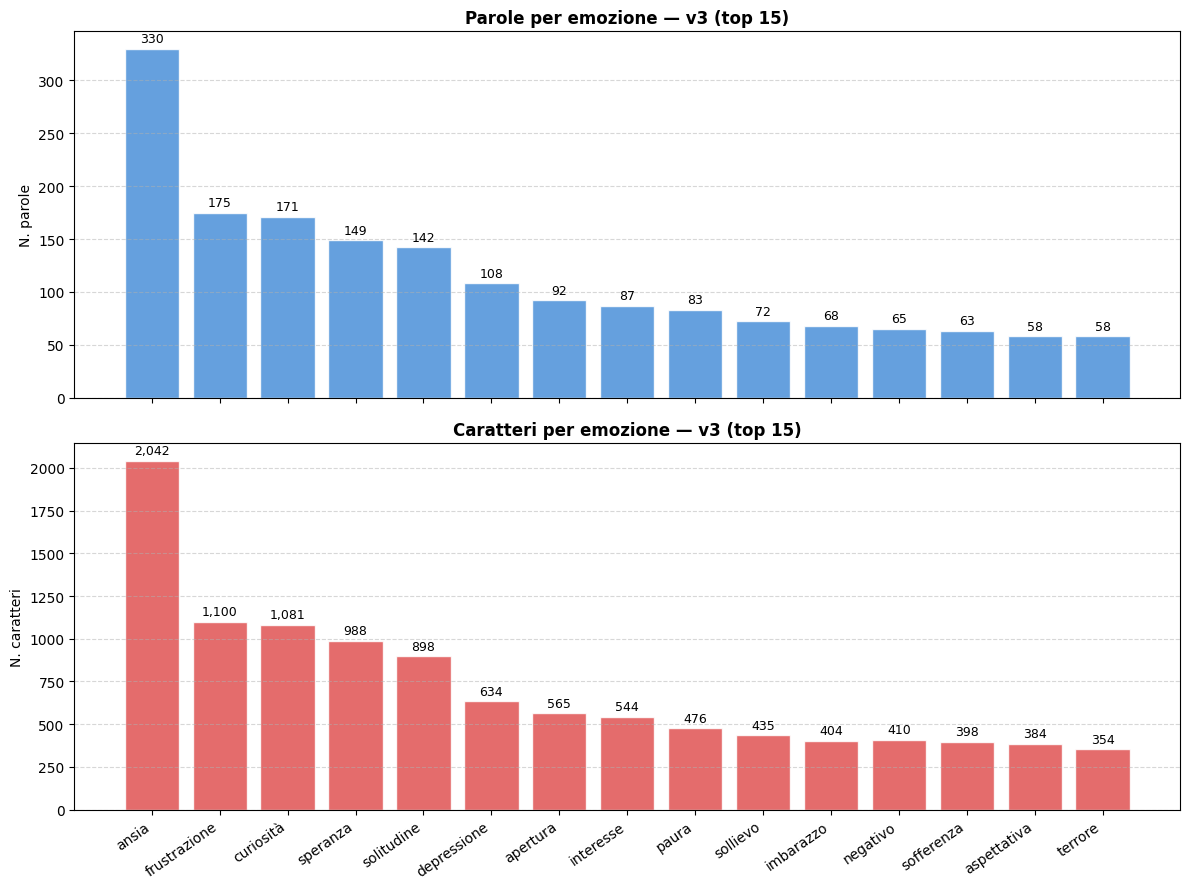

Grafico salvato in 'parole_caratteri_dizionario_v3.png'
Salvati: 'dizionario_periodi_dettaglio_v3.csv' e 'dizionario_periodi_riepilogo_v3.csv'


In [18]:
import re
from collections import defaultdict
import pandas as pd


# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURAZIONE
# ══════════════════════════════════════════════════════════════════════════════

# Intensificatori: token -> categoria di intensita
INTENSIFICATORI = {
    "non": "negazione", "per niente": "negazione", "affatto": "negazione",
    "molto": "alto", "tanto": "alto", "davvero": "alto", "veramente": "alto",
    "assai": "alto", "estremamente": "alto", "totalmente": "alto",
    "completamente": "alto", "profondamente": "alto", "fortemente": "alto",
    "incredibilmente": "alto", "enormemente": "alto", "tremendamente": "alto",
    "abbastanza": "medio", "piuttosto": "medio", "alquanto": "medio",
    "discretamente": "medio",
    "poco": "basso", "appena": "basso", "quasi": "basso",
    "leggermente": "basso", "lievemente": "basso",
    "un po": "basso", "un po'": "basso",
    "moltissimo": "superlativo", "tantissimo": "superlativo",
}
_INT_SORTED = sorted(INTENSIFICATORI.keys(), key=len, reverse=True)
_RE_INTENS  = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in _INT_SORTED) + r")\b",
    re.IGNORECASE
)

# Connettori ADDITIVI: tra due emozioni vicine → stesso blocco → frase condivisa
CONN_ADDITIVI = ["e", "ed", "anche", "nonché", "oltre che", "pure", "inoltre"]

# Espressioni PONTE: indicano intensità/quantità e legano l'emozione al gruppo
# es. "pieno di speranza", "carico di entusiasmo", "colmo di gioia"
ESPRESSIONI_PONTE = [
    "pieno di", "piena di", "pieni di", "piene di",
    "colmo di", "colma di", "colmi di", "colme di",
    "carico di", "carica di", "carichi di",
    "ricco di", "ricca di", "ricchi di",
    "traboccante di", "traboccante",
    "intriso di", "intrisa di",
    "pervaso di", "pervasa di",
    "avvolto da", "avvolta da",
    "pieno", "piena", "colmo", "colma", "carico", "carica",
]

# Congiunzioni che causano lo SPLIT tra blocchi di emozione diversi
CONG_SPLIT = [
    "ma", "però", "tuttavia", "eppure", "anzi", "invece",
    "poi", "dopodiché", "successivamente",
    "mentre", "quando", "sebbene", "benché", "nonostante",
    "al contrario", "d'altra parte", "allora", "quindi", "dunque",
    "perciò", "così", "perché", "poiché", "siccome",
    "se", "oppure", "o", "ovvero", "altrimenti"
]
_RE_SPLIT = re.compile(
    r"(?<=[.!?;])\s+|(?=\b(?:" +
    "|".join(re.escape(c) for c in sorted(CONG_SPLIT, key=len, reverse=True)) +
    r")\b)",
    re.IGNORECASE
)


# ══════════════════════════════════════════════════════════════════════════════
# FUNZIONI DI SUPPORTO
# ══════════════════════════════════════════════════════════════════════════════

def cerca_emozioni_in_testo(testo):
    """Trova tutte le occorrenze emotive con posizione (indici sul testo dato)."""
    trovate = []
    tl = testo.lower()
    for variante, forma_base in MAPPA_INVERSA.items():
        for m in re.finditer(r"\b" + re.escape(variante) + r"\b", tl):
            trovate.append({
                "forma_base": forma_base,
                "variante":   m.group(),
                "start":      m.start(),
                "end":        m.end(),
            })
    trovate.sort(key=lambda x: x["start"])
    return trovate


def trova_intensificatore(testo_periodo, match_start_rel):
    """Cerca un intensificatore nelle 3 parole prima del termine emotivo."""
    frammento = " ".join(testo_periodo[:match_start_rel].split()[-3:]).lower()
    for token in _INT_SORTED:
        if re.search(r"\b" + re.escape(token) + r"\b", frammento):
            return token, INTENSIFICATORI[token]
    return None, None


def emozioni_sono_vicine(testo_periodo, occ_a, occ_b):
    """
    True se tra i due termini emotivi non c'e nulla di semanticamente separante.
    Viene ignorato (rimosso prima del controllo) tutto cio che e:
    - connettori additivi  (e, anche, inoltre...)
    - espressioni ponte    (pieno di, carico di, colmo di...)
    - intensificatori      (molto, abbastanza, totalmente...)
    - virgole e spazi
    """
    tra = testo_periodo[occ_a["end"]:occ_b["start"]].strip().lower()

    # 1. Rimuovi espressioni ponte (piu lunghe prima)
    ponte_sorted = sorted(ESPRESSIONI_PONTE, key=len, reverse=True)
    for esp in ponte_sorted:
        tra = re.sub(r"\b" + re.escape(esp) + r"\b", "", tra)

    # 2. Rimuovi connettori additivi
    tra = re.sub(
        r"\b(" + "|".join(re.escape(c) for c in CONN_ADDITIVI) + r")\b", "", tra
    )

    # 3. Rimuovi intensificatori
    tra = _RE_INTENS.sub("", tra)

    # 4. Rimuovi punteggiatura minore e spazi residui
    tra_pulito = re.sub(r"[,\s]+", "", tra)
    return tra_pulito == ""


def raggruppa_emozioni(testo_periodo, occ_list):
    """
    Raggruppa le occorrenze emotive in blocchi:
    - Emozioni vicine (solo e/anche/virgola in mezzo) -> stesso blocco, frase condivisa
    - Emozioni distanti -> blocchi separati, taglio al punto di mezzo tra i due termini
    Restituisce lista di {emozioni: [...], start: int, end: int}
    """
    if not occ_list:
        return []

    blocchi = [{"emozioni": [occ_list[0]], "start": 0, "end": len(testo_periodo)}]

    for i in range(1, len(occ_list)):
        prev = occ_list[i - 1]
        curr = occ_list[i]
        if emozioni_sono_vicine(testo_periodo, prev, curr):
            blocchi[-1]["emozioni"].append(curr)
        else:
            taglio = (prev["end"] + curr["start"]) // 2
            blocchi[-1]["end"] = taglio
            blocchi.append({
                "emozioni": [curr],
                "start": taglio,
                "end": len(testo_periodo)
            })

    return blocchi


# ══════════════════════════════════════════════════════════════════════════════
# PIPELINE PRINCIPALE
# ══════════════════════════════════════════════════════════════════════════════

def split_in_periodi(testo, min_len=5):
    """Spezza il testo alle congiunzioni avversative e alla punteggiatura forte."""
    periodi = []
    pos = 0
    for parte in re.split(_RE_SPLIT, testo):
        s = parte.strip()
        if len(s) < min_len:
            pos += len(parte)
            continue
        idx = testo.find(s, pos)
        if idx == -1:
            pos += len(parte)
            continue
        periodi.append({"testo": s, "start": idx, "end": idx + len(s)})
        pos = idx + len(s)
    return periodi


def pipeline_risposta(risposta):
    """
    Per ogni risposta:
    1. Spezza in sotto-periodi alle congiunzioni avversative/temporali
    2. In ogni sotto-periodo cerca le emozioni
    3. Raggruppa:
       - emozioni VICINE (e/anche/virgola in mezzo) -> frase intera a entrambe
       - emozioni DISTANTI -> split al punto di mezzo, ciascuna prende il suo pezzo
    4. Aggiunge intensificatore per ogni occorrenza emotiva
    """
    if not risposta:
        return []

    risultati = []

    for periodo in split_in_periodi(risposta):
        testo_p = periodo["testo"]
        occ = cerca_emozioni_in_testo(testo_p)
        if not occ:
            continue

        for blocco in raggruppa_emozioni(testo_p, occ):
            testo_blocco = testo_p[blocco["start"]:blocco["end"]].strip()
            if not testo_blocco:
                continue
            n_parole    = len(testo_blocco.split())
            n_caratteri = len(testo_blocco)

            emo_uniche = list(dict.fromkeys(o["forma_base"] for o in blocco["emozioni"]))

            for emo in emo_uniche:
                occ_emo = next(o for o in blocco["emozioni"] if o["forma_base"] == emo)
                start_rel = occ_emo["start"] - blocco["start"]
                intens, intens_cat = trova_intensificatore(testo_blocco, start_rel)

                risultati.append({
                    "testo":               testo_blocco,
                    "emozione":            emo,
                    "intensificatore":     intens,
                    "intensificatore_cat": intens_cat,
                    "n_parole":            n_parole,
                    "n_caratteri":         n_caratteri,
                })

    return risultati


print("Funzioni sezione 8 v3 definite")


# ── Demo ──────────────────────────────────────────────────────────────────────

_DEMO = [
    "Ero molto felice perche Gaia mi ha abbracciato ma poi mi sono sentito triste.",
    "Ero molto felice e contento perche mi hanno fatto un regalo.",
    "Non ero per niente soddisfatto ma abbastanza sereno lo stesso.",
    "Mi sentivo gioioso, entusiasta e pieno di speranza.",
    "Ero sereno mentre loro erano preoccupati.",
]

_SEP = "─" * 80

def _stampa_analisi(frase):
    tot_par = len(frase.split())
    tot_car = len(frase)
    rs = pipeline_risposta(frase)
    print(f"\n{_SEP}")
    print(f'FRASE: "{frase}"')
    print(f"Totale risposta → {tot_par} parole · {tot_car} caratteri")
    print(_SEP)
    if not rs:
        print("  → nessuna emozione rilevata")
        return
    COL = f"  {'EMOZIONE':<18} {'INTENSIFICATORE':<26} {'PAR':>4} {'%PAR':>6}  {'CAR':>4} {'%CAR':>6}   TESTO ATTRIBUITO"
    print(COL)
    print("  " + "─"*18 + " " + "─"*26 + " " + "─"*4 + " " + "─"*6 + "  " + "─"*4 + " " + "─"*6 + "   " + "─"*28)
    for r in rs:
        perc_par = round(r["n_parole"]    / tot_par * 100, 1) if tot_par else 0
        perc_car = round(r["n_caratteri"] / tot_car * 100, 1) if tot_car else 0
        i_str = f"{r['intensificatore']} [{r['intensificatore_cat']}]" if r["intensificatore"] else "—"
        testo_breve = r["testo"][:36] + ("…" if len(r["testo"]) > 36 else "")
        print(f"  {r['emozione']:<18} {i_str:<26} {r['n_parole']:>4} {perc_par:>5.1f}%  {r['n_caratteri']:>4} {perc_car:>5.1f}%   \"{testo_breve}\"")

print("\n" + "=" * 80)
print("  DEMO — esempi di analisi")
print("=" * 80)
for frase in _DEMO:
    _stampa_analisi(frase)
print(f"\n{_SEP}")


# ── Salvataggio PDF della demo ────────────────────────────────────────────────

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable

def _colore_intensif(cat):
    return {
        "negazione":   colors.HexColor("#c0392b"),
        "basso":       colors.HexColor("#e67e22"),
        "medio":       colors.HexColor("#2980b9"),
        "alto":        colors.HexColor("#27ae60"),
        "superlativo": colors.HexColor("#8e44ad"),
    }.get(cat, colors.black)

def _build_table_pdf(rs, tot_par, tot_car):
    header = ["EMOZIONE", "INTENSIFICATORE", "PAR", "%PAR", "CAR", "%CAR", "TESTO ATTRIBUITO"]
    data = [header]
    for r in rs:
        perc_par = round(r["n_parole"]    / tot_par * 100, 1) if tot_par else 0
        perc_car = round(r["n_caratteri"] / tot_car * 100, 1) if tot_car else 0
        i_str = f"{r['intensificatore']} [{r['intensificatore_cat']}]" if r["intensificatore"] else "—"
        testo = r["testo"][:45] + ("…" if len(r["testo"]) > 45 else "")
        data.append([
            r["emozione"], i_str,
            str(r["n_parole"]),    f"{perc_par:.1f}%",
            str(r["n_caratteri"]), f"{perc_car:.1f}%",
            testo
        ])
    col_w = [30*mm, 40*mm, 10*mm, 12*mm, 10*mm, 12*mm, 46*mm]
    t = Table(data, colWidths=col_w)
    _HEADER_BG = colors.HexColor("#2c3e50")
    _BORDER    = colors.HexColor("#bdc3c7")
    t.setStyle(TableStyle([
        ("BACKGROUND",   (0,0), (-1,0), _HEADER_BG),
        ("TEXTCOLOR",    (0,0), (-1,0), colors.white),
        ("FONTNAME",     (0,0), (-1,0), "Helvetica-Bold"),
        ("FONTSIZE",     (0,0), (-1,0), 7),
        ("ALIGN",        (0,0), (-1,0), "CENTER"),
        ("BOTTOMPADDING",(0,0), (-1,0), 5),
        ("TOPPADDING",   (0,0), (-1,0), 5),
        ("FONTNAME",     (0,1), (-1,-1), "Helvetica"),
        ("FONTSIZE",     (0,1), (-1,-1), 7.5),
        ("ALIGN",        (2,1), (5,-1), "CENTER"),
        ("ALIGN",        (0,1), (1,-1), "LEFT"),
        ("ALIGN",        (6,1), (6,-1), "LEFT"),
        ("TOPPADDING",   (0,1), (-1,-1), 4),
        ("BOTTOMPADDING",(0,1), (-1,-1), 4),
        ("GRID",         (0,0), (-1,-1), 0.4, _BORDER),
        ("ROWBACKGROUNDS",(0,1),(-1,-1), [colors.white, colors.HexColor("#f4f6f7")]),
    ]))
    return t

def salva_demo_pdf(frasi, percorso="demo_analisi_sentiment.pdf"):
    st_title  = ParagraphStyle("t",  fontSize=16, fontName="Helvetica-Bold",
                                spaceAfter=6, textColor=colors.HexColor("#1a1a2e"))
    st_frase  = ParagraphStyle("f",  fontSize=9,  fontName="Helvetica-Bold",
                                spaceAfter=2, textColor=colors.HexColor("#2c3e50"))
    st_totale = ParagraphStyle("to", fontSize=8,  fontName="Helvetica-Oblique",
                                spaceAfter=4, textColor=colors.HexColor("#7f8c8d"))
    st_empty  = ParagraphStyle("e",  fontSize=8,  fontName="Helvetica")

    doc = SimpleDocTemplate(
        percorso, pagesize=A4,
        leftMargin=15*mm, rightMargin=15*mm,
        topMargin=18*mm,  bottomMargin=18*mm
    )
    story = []
    story.append(Paragraph("Analisi del Sentiment — Demo Esempi", st_title))
    story.append(HRFlowable(width="100%", thickness=1,
                             color=colors.HexColor("#2c3e50"), spaceAfter=8))

    for frase in frasi:
        tot_par = len(frase.split())
        tot_car = len(frase)
        rs = pipeline_risposta(frase)
        story.append(Paragraph(f'Frase: "{frase}"', st_frase))
        story.append(Paragraph(
            f"Totale risposta → {tot_par} parole · {tot_car} caratteri", st_totale))
        if not rs:
            story.append(Paragraph("→ nessuna emozione rilevata", st_empty))
        else:
            story.append(_build_table_pdf(rs, tot_par, tot_car))
        story.append(Spacer(1, 8*mm))

    doc.build(story)
    print(f"PDF salvato in '{percorso}'")

salva_demo_pdf(_DEMO)


# ══════════════════════════════════════════════════════════════════════════════
# ESECUZIONE SU TUTTI I FILE
# ══════════════════════════════════════════════════════════════════════════════

righe_diz = []
totali_emozione = defaultdict(lambda: {"periodi": 0, "parole": 0, "caratteri": 0})

for dati in dati_grezzi:
    for idx, (domanda, risposta) in enumerate(zip(dati["domande"], dati["risposte"])):
        if not risposta:
            continue
        tot_par = len(risposta.split())
        tot_car = len(risposta)
        for sp in pipeline_risposta(risposta):
            e = sp["emozione"]
            totali_emozione[e]["periodi"]   += 1
            totali_emozione[e]["parole"]    += sp["n_parole"]
            totali_emozione[e]["caratteri"] += sp["n_caratteri"]
            righe_diz.append({
                "file":                dati["file"],
                "numero":              dati["numero"],
                "domanda_n":           idx + 1,
                "emozione":            e,
                "intensificatore":     sp["intensificatore"],
                "intensificatore_cat": sp["intensificatore_cat"],
                "periodo":             sp["testo"],
                "n_parole":            sp["n_parole"],
                "n_caratteri":         sp["n_caratteri"],
                "tot_par_risposta":    tot_par,
                "tot_car_risposta":    tot_car,
                "perc_parole":    round(sp["n_parole"]    / tot_par * 100, 1) if tot_par else 0,
                "perc_caratteri": round(sp["n_caratteri"] / tot_car * 100, 1) if tot_car else 0,
            })

df_diz = pd.DataFrame(righe_diz)
print(f"\nAnalisi completata: {len(df_diz)} occorrenze estratte")


# ── Tabella riepilogativa ─────────────────────────────────────────────────────

tot_par_glob = sum(v["parole"]    for v in totali_emozione.values())
tot_car_glob = sum(v["caratteri"] for v in totali_emozione.values())
tot_per_glob = sum(v["periodi"]   for v in totali_emozione.values())

print("\n" + "="*80)
print("  CARATTERI E PAROLE PER EMOZIONE — v3")
print("="*80)
print(f"  {'':22} {'Periodi':>8} {'%':>6}  {'Parole':>8} {'%':>6}  {'Caratteri':>10} {'%':>6}")
print("  " + "-"*75)
for e, v in sorted(totali_emozione.items(), key=lambda x: -x[1]["parole"]):
    pp  = round(v["periodi"]   / tot_per_glob * 100, 1) if tot_per_glob else 0
    ppa = round(v["parole"]    / tot_par_glob * 100, 1) if tot_par_glob else 0
    pc  = round(v["caratteri"] / tot_car_glob * 100, 1) if tot_car_glob else 0
    print(f"  {e:<22} {v['periodi']:>8}  {pp:>5.1f}%  {v['parole']:>8}  {ppa:>5.1f}%  {v['caratteri']:>10}  {pc:>5.1f}%")
print("  " + "-"*75)
print(f"  {'TOTALE':<22} {tot_per_glob:>8}  {'100.0':>5}%  {tot_par_glob:>8}  {'100.0':>5}%  {tot_car_glob:>10}  {'100.0':>5}%")


# ── Riepilogo intensificatori ─────────────────────────────────────────────────

if len(df_diz) > 0:
    df_int = df_diz[df_diz["intensificatore"].notna()]
    print(f"\n{'='*55}")
    print("  INTENSIFICATORI RILEVATI")
    print(f"{'='*55}")
    print(f"  Con intensificatore: {len(df_int)} / {len(df_diz)} occorrenze")
    for (tok, cat), grp in df_int.groupby(["intensificatore", "intensificatore_cat"]):
        print(f"  {tok:<22} ({cat:<12})  {len(grp):>4}x")


# ── Grafico ───────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

top = sorted(totali_emozione.items(), key=lambda x: -x[1]["parole"])[:15]
etichette  = [e for e, _ in top]
val_parole = [v["parole"]    for _, v in top]
val_car    = [v["caratteri"] for _, v in top]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
ax1.bar(etichette, val_parole, color="#4a90d9", alpha=0.85, edgecolor="white")
ax1.set_ylabel("N. parole")
ax1.set_title("Parole per emozione — v3 (top 15)", fontweight="bold")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate(val_parole):
    ax1.text(i, v + max(val_parole)*0.01, str(v), ha="center", va="bottom", fontsize=9)
ax2.bar(etichette, val_car, color="#e05252", alpha=0.85, edgecolor="white")
ax2.set_ylabel("N. caratteri")
ax2.set_title("Caratteri per emozione — v3 (top 15)", fontweight="bold")
ax2.grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate(val_car):
    ax2.text(i, v + max(val_car)*0.01, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=35, ha="right", fontsize=10)
plt.tight_layout()
plt.savefig("parole_caratteri_dizionario_v3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato in 'parole_caratteri_dizionario_v3.png'")


# ── Export CSV ────────────────────────────────────────────────────────────────

df_diz.to_csv("dizionario_periodi_dettaglio_v3.csv", index=False, encoding="utf-8-sig")
df_riepilogo = pd.DataFrame([
    {"emozione": e,
     "periodi":        v["periodi"],
     "perc_periodi":   round(v["periodi"]   / tot_per_glob * 100, 1) if tot_per_glob else 0,
     "parole":         v["parole"],
     "perc_parole":    round(v["parole"]    / tot_par_glob * 100, 1) if tot_par_glob else 0,
     "caratteri":      v["caratteri"],
     "perc_caratteri": round(v["caratteri"] / tot_car_glob * 100, 1) if tot_car_glob else 0}
    for e, v in sorted(totali_emozione.items(), key=lambda x: -x[1]["parole"])
])
df_riepilogo.to_csv("dizionario_periodi_riepilogo_v3.csv", index=False, encoding="utf-8-sig")
print("Salvati: 'dizionario_periodi_dettaglio_v3.csv' e 'dizionario_periodi_riepilogo_v3.csv'")


## 9. Word cloud interattivo — emozioni per partecipante e globale

Visualizzazione interattiva delle parole emotive trovate dal dizionario.
La dimensione di ogni termine è proporzionale alla sua frequenza.

- **Vista globale**: tutte le occorrenze su tutti i partecipanti e domande
- **Vista per partecipante**: seleziona il numero del file per vedere il suo profilo emotivo
- Il colore indica la categoria emotiva (gioia, tristezza, paura, rabbia, altro)
- Richiede `matplotlib`, `numpy` — già disponibili nell'ambiente standard

Generazione word cloud GLOBALE...


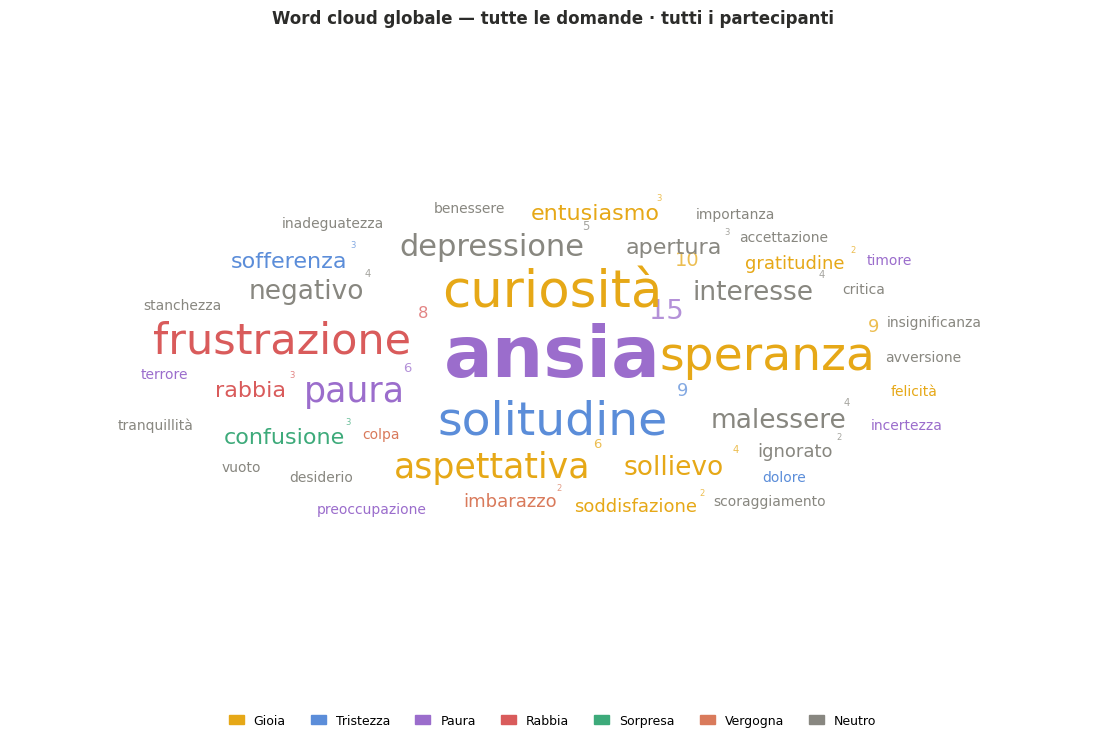

✅ Salvato: 'wordcloud_globale.png'

Generazione word cloud per PARTECIPANTE...


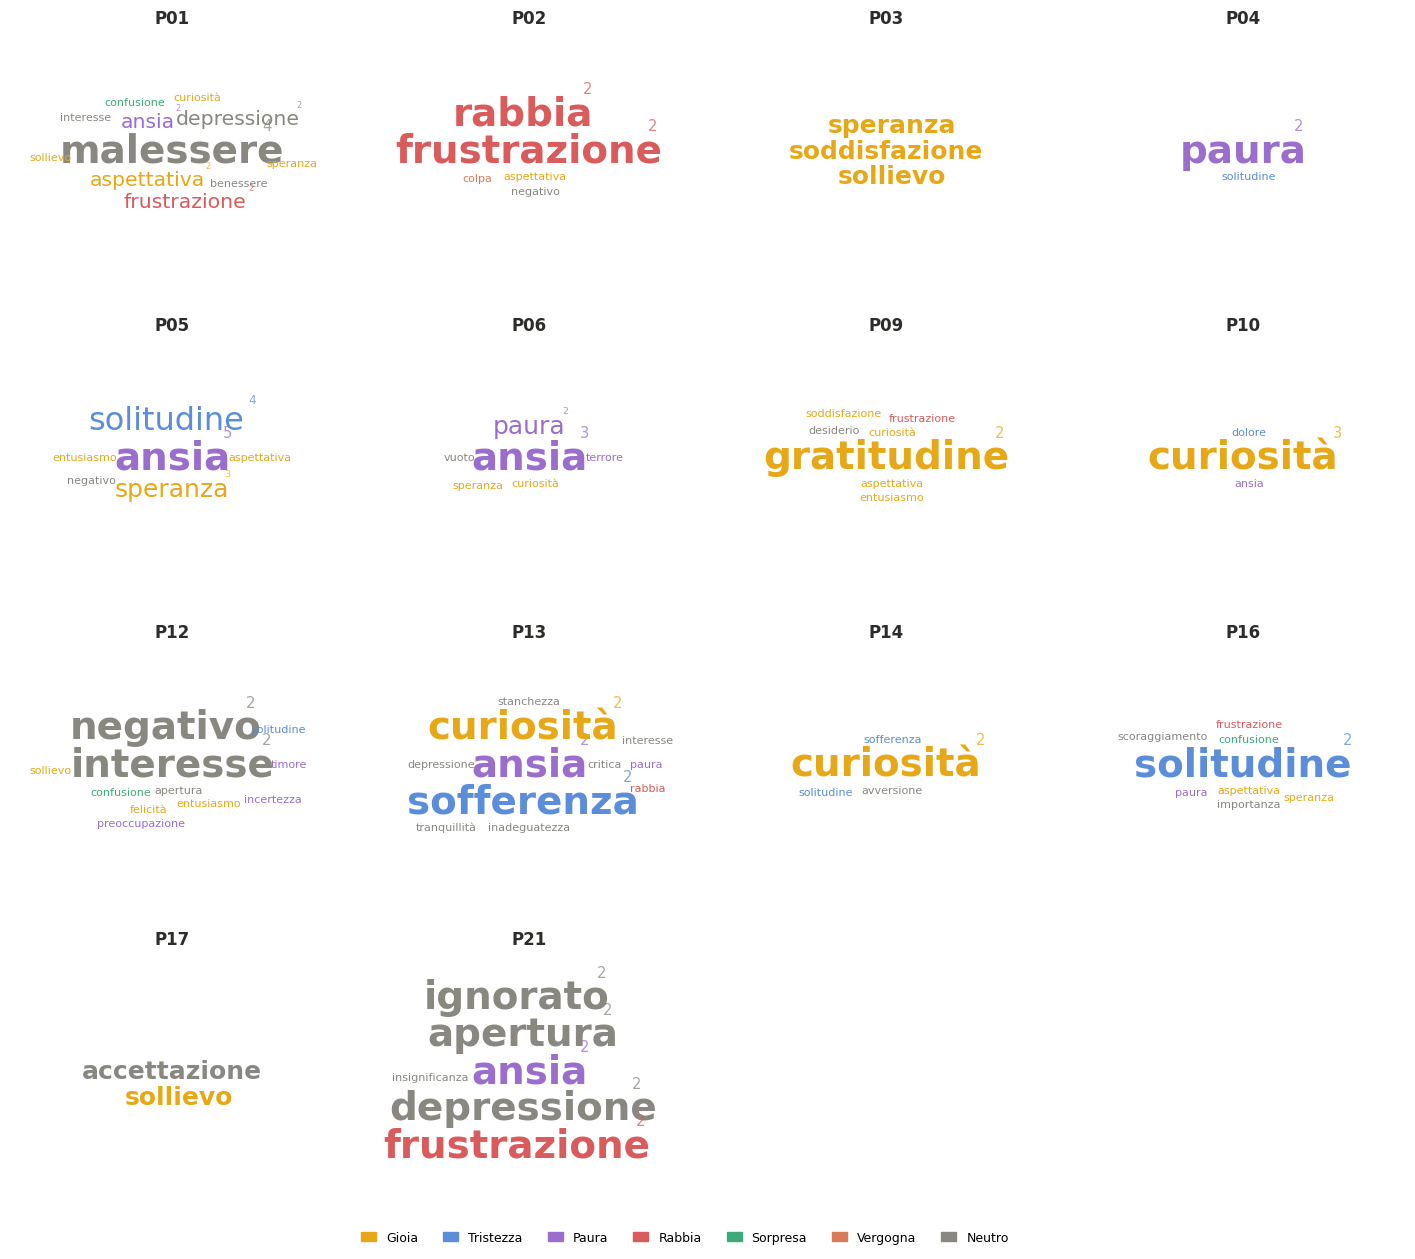

✅ Salvato: 'wordcloud_partecipanti.png'

Generazione word cloud per DOMANDA...


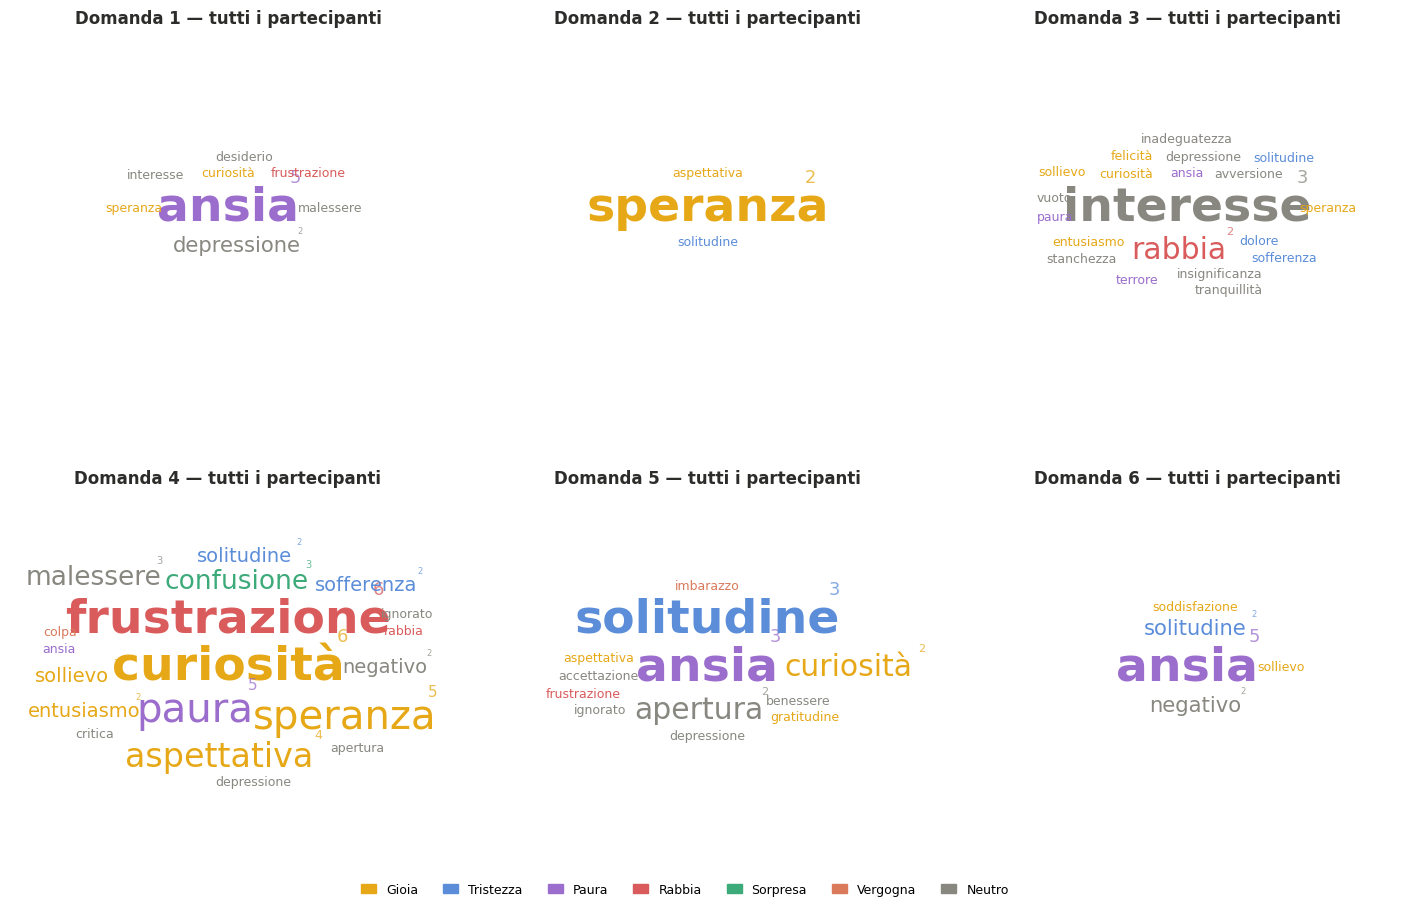

✅ Salvato: 'wordcloud_domande.png'

✅ Sezione 9 completata — 3 file PNG generati:
   • wordcloud_globale.png
   • wordcloud_partecipanti.png
   • wordcloud_domande.png


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# SEZIONE 9 — Word cloud interattivo (dizionario)
# Dipende da: df_emozioni (cella 4f) e df_diz (cella 8)
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Palette colori per categoria emotiva ─────────────────────────────────────

PALETTE = {
    'gioia':      '#e6a817',  # ambra
    'tristezza':  '#5b8dd9',  # blu
    'paura':      '#9b6dcc',  # viola
    'rabbia':     '#d95b5b',  # rosso
    'sorpresa':   '#3daa7a',  # verde
    'vergogna':   '#d97a5b',  # corallo
    'neutro':     '#888780',  # grigio
}

# Mappa emozione → categoria
CATEGORIE = {
    'gioia': 'gioia', 'felicità': 'gioia', 'entusiasmo': 'gioia',
    'sollievo': 'gioia', 'speranza': 'gioia', 'soddisfazione': 'gioia',
    'curiosità': 'gioia', 'gratitudine': 'gioia', 'orgoglio': 'gioia',
    'fiducia': 'gioia', 'serenità': 'gioia', 'ottimismo': 'gioia',
    'amore': 'gioia', 'affetto': 'gioia', 'aspettativa': 'gioia',
    'tristezza': 'tristezza', 'malinconia': 'tristezza', 'dolore': 'tristezza',
    'sofferenza': 'tristezza', 'dispiacere': 'tristezza', 'delusione': 'tristezza',
    'sconforto': 'tristezza', 'disperazione': 'tristezza', 'solitudine': 'tristezza',
    'rimpianto': 'tristezza',
    'paura': 'paura', 'ansia': 'paura', 'preoccupazione': 'paura',
    'timore': 'paura', 'terrore': 'paura', 'angoscia': 'paura',
    'inquietudine': 'paura', 'insicurezza': 'paura', 'incertezza': 'paura',
    'vulnerabilità': 'paura',
    'rabbia': 'rabbia', 'frustrazione': 'rabbia', 'irritazione': 'rabbia',
    'risentimento': 'rabbia', 'indignazione': 'rabbia', 'collera': 'rabbia',
    'odio': 'rabbia',
    'sorpresa': 'sorpresa', 'stupore': 'sorpresa', 'confusione': 'sorpresa',
    'disorientamento': 'sorpresa', 'meraviglia': 'sorpresa',
    'vergogna': 'vergogna', 'colpa': 'vergogna', 'imbarazzo': 'vergogna',
    'malessere': 'neutro', 'benessere': 'neutro', 'stanchezza': 'neutro',
    'nostalgia': 'neutro',
}


def get_colore(emozione):
    cat = CATEGORIE.get(emozione, 'neutro')
    return PALETTE[cat]


# ── Funzione word cloud ───────────────────────────────────────────────────────

def disegna_word_cloud(ax, conteggi: dict, titolo: str,
                       max_parole: int = 40,
                       font_min: float = 9,
                       font_max: float = 46):
    """
    Posiziona le parole con un layout a spirale che evita le sovrapposizioni.
    conteggi: dict {forma_base: count}
    """
    if not conteggi:
        ax.text(0.5, 0.5, 'Nessuna emozione trovata',
                ha='center', va='center', fontsize=11,
                color='#888', transform=ax.transAxes)
        ax.set_title(titolo, fontsize=12, fontweight='bold', pad=10)
        ax.axis('off')
        return

    # Ordina per frequenza, tieni le top N
    ordinati = sorted(conteggi.items(), key=lambda x: -x[1])[:max_parole]
    freq_max = ordinati[0][1]
    freq_min = ordinati[-1][1]

    def scala_font(freq):
        if freq_max == freq_min:
            return (font_min + font_max) / 2
        t = (freq - freq_min) / (freq_max - freq_min)
        return font_min + t * (font_max - font_min)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(titolo, fontsize=12, fontweight='bold', pad=10,
                 color='#2c2c2a')

    rng = np.random.default_rng(seed=42)
    posizionate = []  # (x, y, w, h) in dati normalizzati

    fig = ax.get_figure()
    renderer = fig.canvas.get_renderer()
    ax_w, ax_h = ax.get_position().width * fig.get_size_inches()[0], \
                 ax.get_position().height * fig.get_size_inches()[1]

    def bbox_ok(x, y, bw, bh, pad=0.015):
        """Controlla se il bounding box non esce dai bordi e non si sovrappone."""
        if x - bw/2 < pad or x + bw/2 > 1 - pad:
            return False
        if y - bh/2 < pad or y + bh/2 > 1 - pad:
            return False
        for (px, py, pw, ph) in posizionate:
            if (abs(x - px) < (bw + pw) / 2 + 0.01 and
                    abs(y - py) < (bh + ph) / 2 + 0.01):
                return False
        return True

    for parola, freq in ordinati:
        fs = scala_font(freq)
        colore = get_colore(parola)

        # Stima dimensione in coordinate normalizzate
        bw = len(parola) * fs * 0.007 / ax_w + 0.01
        bh = fs * 0.012 / ax_h + 0.005

        # Cerca posizione libera a spirale
        posizionata = False
        for raggio in np.arange(0, 0.5, 0.018):
            angoli = rng.permutation(
                np.linspace(0, 2 * np.pi, max(8, int(raggio * 80) + 1), endpoint=False)
            )
            for ang in angoli:
                x = 0.5 + raggio * np.cos(ang)
                y = 0.5 + raggio * np.sin(ang) * 0.7
                if bbox_ok(x, y, bw, bh):
                    ax.text(x, y, parola,
                            fontsize=fs,
                            ha='center', va='center',
                            color=colore,
                            fontweight='bold' if freq == freq_max else 'normal',
                            transform=ax.transAxes)
                    # Mostra conteggio come apice se > 1
                    if freq > 1:
                        ax.text(x + bw/2, y + bh/2, str(freq),
                                fontsize=max(6, fs * 0.38),
                                ha='left', va='bottom',
                                color=colore, alpha=0.75,
                                transform=ax.transAxes)
                    posizionate.append((x, y, bw, bh))
                    posizionata = True
                    break
            if posizionata:
                break


def legenda_categorie(ax):
    """Aggiunge una legenda orizzontale delle categorie emotive."""
    handles = [
        mpatches.Patch(color=col, label=cat.capitalize())
        for cat, col in PALETTE.items()
    ]
    ax.legend(handles=handles, loc='upper center',
              bbox_to_anchor=(0.5, -0.04),
              ncol=len(PALETTE), fontsize=9,
              frameon=False, handlelength=1.2)


# ── VISTA GLOBALE ─────────────────────────────────────────────────────────────

print("Generazione word cloud GLOBALE...")

conteggi_globali = (
    df_emozioni[df_emozioni['metodo'] == 'dizionario']
    .groupby('forma_base')
    .size()
    .to_dict()
)

fig_glob, ax_glob = plt.subplots(figsize=(14, 8))
fig_glob.subplots_adjust(bottom=0.08)
disegna_word_cloud(ax_glob, conteggi_globali,
                   titolo='Word cloud globale — tutte le domande · tutti i partecipanti',
                   max_parole=50, font_min=10, font_max=52)
legenda_categorie(ax_glob)
plt.savefig('wordcloud_globale.png', dpi=150, bbox_inches='tight',
            facecolor='#f8f8f6')
plt.show()
print("✅ Salvato: 'wordcloud_globale.png'")


# ── VISTA PER PARTECIPANTE ────────────────────────────────────────────────────

print("\nGenerazione word cloud per PARTECIPANTE...")

numeri = sorted(df_emozioni['numero'].unique())
n = len(numeri)
cols = 4
rows = -(-n // cols)  # ceil division

fig_part, axes = plt.subplots(rows, cols,
                               figsize=(cols * 4.5, rows * 3.5))
fig_part.subplots_adjust(hspace=0.35, wspace=0.1, bottom=0.06)
axes_flat = axes.flatten() if rows > 1 else axes

for i, num in enumerate(numeri):
    df_part = df_emozioni[
        (df_emozioni['numero'] == num) &
        (df_emozioni['metodo'] == 'dizionario')
    ]
    conteggi_part = df_part.groupby('forma_base').size().to_dict()
    disegna_word_cloud(axes_flat[i], conteggi_part,
                       titolo=f'P{num:02d}',
                       max_parole=20, font_min=8, font_max=28)

# Nascondi assi vuoti
for j in range(len(numeri), len(axes_flat)):
    axes_flat[j].axis('off')

# Legenda unica in fondo
handles = [
    mpatches.Patch(color=col, label=cat.capitalize())
    for cat, col in PALETTE.items()
]
fig_part.legend(handles=handles, loc='lower center',
                ncol=len(PALETTE), fontsize=9,
                frameon=False, handlelength=1.2, bbox_to_anchor=(0.5, 0.01))

plt.savefig('wordcloud_partecipanti.png', dpi=150, bbox_inches='tight',
            facecolor='#f8f8f6')
plt.show()
print("✅ Salvato: 'wordcloud_partecipanti.png'")


# ── VISTA PER DOMANDA (globale) ───────────────────────────────────────────────

print("\nGenerazione word cloud per DOMANDA...")

domande_n = sorted(df_emozioni['domanda_n'].unique())
fig_dom, axes_dom = plt.subplots(2, 3, figsize=(18, 10))
fig_dom.subplots_adjust(hspace=0.35, wspace=0.1, bottom=0.08)

for i, dn in enumerate(domande_n[:6]):
    df_d = df_emozioni[
        (df_emozioni['domanda_n'] == dn) &
        (df_emozioni['metodo'] == 'dizionario')
    ]
    conteggi_d = df_d.groupby('forma_base').size().to_dict()
    ax_d = axes_dom.flatten()[i]
    disegna_word_cloud(ax_d, conteggi_d,
                       titolo=f'Domanda {dn} — tutti i partecipanti',
                       max_parole=25, font_min=9, font_max=34)

fig_dom.legend(handles=handles, loc='lower center',
               ncol=len(PALETTE), fontsize=9,
               frameon=False, handlelength=1.2, bbox_to_anchor=(0.5, 0.01))

plt.savefig('wordcloud_domande.png', dpi=150, bbox_inches='tight',
            facecolor='#f8f8f6')
plt.show()
print("✅ Salvato: 'wordcloud_domande.png'")
print("\n✅ Sezione 9 completata — 3 file PNG generati:")
print("   • wordcloud_globale.png")
print("   • wordcloud_partecipanti.png")
print("   • wordcloud_domande.png")